# Acess-logs-2

IP malevoli: 151.59.2.55, 151.59.5.47

## Preprocessing

In [12]:
import pandas as pd

df = pd.read_csv("datasets/access-logs-2.csv")
df.columns = [
    "timestamp",
    "IntervalDateTime",
    "Total",
    "Response_bytes",
    "Method",
    "Response",
    "host",
    "IP"
]
df.head()

,timestamp,IntervalDateTime,Total,Response_bytes,Method,Response,host,IP
0,1.775520e+09,07/Apr/2026:00:00:56-07/Apr/2026:00:00:56,1,127320,GET,20x,www.sardegnasolidale.it,185.112.144.11
1,1.775520e+09,07/Apr/2026:00:00:54-07/Apr/2026:00:00:54,1,15689,GET,20x,www.sardegnasolidale.it,54.38.147.133
2,1.775520e+09,07/Apr/2026:00:01:04-07/Apr/2026:00:01:04,1,31,POST,20x,www.sardegnasolidale.it,80.211.146.125
3,1.775520e+09,07/Apr/2026:00:01:04-07/Apr/2026:00:01:04,1,450,GET,20x,www.sardegnasolidale.it,207.180.11.166
4,1.775520e+09,07/Apr/2026:00:01:25-07/Apr/2026:00:01:25,1,15291,GET,20x,www.sardegnasolidale.it,198.244.242.173


In [14]:
# labeling the attack ips
malicious_ips = [
"151.59.2.55",
"151.59.5.47"
]

df["label"] = df["IP"].isin(malicious_ips).astype(int)
print(df["label"].value_counts())
df.head()

label
0    23247
1     5176
Name: count, dtype: int64


,timestamp,IntervalDateTime,Total,Response_bytes,Method,Response,host,IP,label
0,1.775520e+09,07/Apr/2026:00:00:56-07/Apr/2026:00:00:56,1,127320,GET,20x,www.sardegnasolidale.it,185.112.144.11,0
1,1.775520e+09,07/Apr/2026:00:00:54-07/Apr/2026:00:00:54,1,15689,GET,20x,www.sardegnasolidale.it,54.38.147.133,0
2,1.775520e+09,07/Apr/2026:00:01:04-07/Apr/2026:00:01:04,1,31,POST,20x,www.sardegnasolidale.it,80.211.146.125,0
3,1.775520e+09,07/Apr/2026:00:01:04-07/Apr/2026:00:01:04,1,450,GET,20x,www.sardegnasolidale.it,207.180.11.166,0
4,1.775520e+09,07/Apr/2026:00:01:25-07/Apr/2026:00:01:25,1,15291,GET,20x,www.sardegnasolidale.it,198.244.242.173,0


In [4]:
desired_order = [
    "host",
    "IP",
    "IntervalDateTime",
    "start",
    "end",
    "duration_sec",
    "Total",
    "Method",
    "Response",
    "Response_bytes",
    "label"
]

In [15]:
df[["start", "end"]] = (
    df["IntervalDateTime"]
    .astype(str)
    .str.replace('"', '', regex=False)
    .str.split("-", expand=True)
)

df["start"] = pd.to_datetime(df["start"], format="%d/%b/%Y:%H:%M:%S", errors="coerce")
df["end"]   = pd.to_datetime(df["end"],   format="%d/%b/%Y:%H:%M:%S", errors="coerce")

df["duration_sec"] = (df["end"] - df["start"]).dt.total_seconds()

df = df.reindex(columns=desired_order)

df.head()

,host,IP,IntervalDateTime,start,end,duration_sec,Total,Method,Response,Response_bytes,label
0,www.sardegnasolidale.it,185.112.144.11,07/Apr/2026:00:00:56-07/Apr/2026:00:00:56,2026-04-07 00:00:56,2026-04-07 00:00:56,0.0,1,GET,20x,127320,0
1,www.sardegnasolidale.it,54.38.147.133,07/Apr/2026:00:00:54-07/Apr/2026:00:00:54,2026-04-07 00:00:54,2026-04-07 00:00:54,0.0,1,GET,20x,15689,0
2,www.sardegnasolidale.it,80.211.146.125,07/Apr/2026:00:01:04-07/Apr/2026:00:01:04,2026-04-07 00:01:04,2026-04-07 00:01:04,0.0,1,POST,20x,31,0
3,www.sardegnasolidale.it,207.180.11.166,07/Apr/2026:00:01:04-07/Apr/2026:00:01:04,2026-04-07 00:01:04,2026-04-07 00:01:04,0.0,1,GET,20x,450,0
4,www.sardegnasolidale.it,198.244.242.173,07/Apr/2026:00:01:25-07/Apr/2026:00:01:25,2026-04-07 00:01:25,2026-04-07 00:01:25,0.0,1,GET,20x,15291,0


In [16]:
# Encode categorical features
# # Response -> ordinal
# response_map = {
#     "20x": 0, # normal
#     "30x": 1, # transitional
#     "40x": 2, # problematic
#     "49x": 3  # suspicious
# }
# df["Response"] = df["Response"].map(response_map)

# IP -> frequency encoding
df["IP_freq"] = df["IP"].map(df["IP"].value_counts())

# Method -> dummy encoding
df = pd.get_dummies(df, columns=["Method"], drop_first=False, dtype=int)

df.head()

,host,IP,IntervalDateTime,start,end,duration_sec,Total,Response,Response_bytes,label,IP_freq,Method_GET,Method_OTHER,Method_POST
0,www.sardegnasolidale.it,185.112.144.11,07/Apr/2026:00:00:56-07/Apr/2026:00:00:56,2026-04-07 00:00:56,2026-04-07 00:00:56,0.0,1,20x,127320,0,1,1,0,0
1,www.sardegnasolidale.it,54.38.147.133,07/Apr/2026:00:00:54-07/Apr/2026:00:00:54,2026-04-07 00:00:54,2026-04-07 00:00:54,0.0,1,20x,15689,0,4,1,0,0
2,www.sardegnasolidale.it,80.211.146.125,07/Apr/2026:00:01:04-07/Apr/2026:00:01:04,2026-04-07 00:01:04,2026-04-07 00:01:04,0.0,1,20x,31,0,3495,0,0,1
3,www.sardegnasolidale.it,207.180.11.166,07/Apr/2026:00:01:04-07/Apr/2026:00:01:04,2026-04-07 00:01:04,2026-04-07 00:01:04,0.0,1,20x,450,0,1,1,0,0
4,www.sardegnasolidale.it,198.244.242.173,07/Apr/2026:00:01:25-07/Apr/2026:00:01:25,2026-04-07 00:01:25,2026-04-07 00:01:25,0.0,1,20x,15291,0,1,1,0,0


In [17]:
# Drop unnecessary columns
df = df.drop(["IntervalDateTime", "host", "start", "end", "IP", "Response"], axis=1)

df.head()

,duration_sec,Total,Response_bytes,label,IP_freq,Method_GET,Method_OTHER,Method_POST
0,0.0,1,127320,0,1,1,0,0
1,0.0,1,15689,0,4,1,0,0
2,0.0,1,31,0,3495,0,0,1
3,0.0,1,450,0,1,1,0,0
4,0.0,1,15291,0,1,1,0,0


In [18]:
# Check NA values
df.isna().sum()

# # Drop NA values
# df = df.dropna()

duration_sec      0
Total             0
Response_bytes    0
label             0
IP_freq           0
Method_GET        0
Method_OTHER      0
Method_POST       0
dtype: int64

In [19]:
# Check negative values (to avoid making NA in log trasnform)
(df.select_dtypes(include="number") <= -1).sum()

# Drop negative values (before log transform)
df = df[(df > -1).all(axis=1)]

In [20]:
# Normalize values (min max scaler)
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import joblib

# Log-transform skewed features
df["duration_sec"] = np.log1p(df["duration_sec"])
df["Response_bytes"] = np.log1p(df["Response_bytes"])
df["IP_freq"] = np.log1p(df["IP_freq"])
df["Total"] = np.log1p(df["Total"])

# Scale selected features
features_to_scale = ["duration_sec", "Response_bytes", "IP_freq", "Total"]

scaler = joblib.load("access-2-scaler.pkl")
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])
df = df.reindex(columns=["duration_sec", "Total", "Response_bytes", "IP_freq", "Method_GET", "Method_OTHER", "Method_POST", "label"])
df.head()

,duration_sec,Total,Response_bytes,IP_freq,Method_GET,Method_OTHER,Method_POST,label
0,0.0,0.0,0.668448,0.000000,1,0,0,0
1,0.0,0.0,0.549385,0.118007,1,0,0,0
2,0.0,0.0,0.197088,0.961558,0,0,1,0
3,0.0,0.0,0.347544,0.000000,1,0,0,0
4,0.0,0.0,0.547924,0.000000,1,0,0,0


In [21]:
df['label'].value_counts()

label
0    23246
1     5176
Name: count, dtype: int64

## Random Forest

In [22]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop(columns=["label"])
y = df["label"]

# Split real dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape, "\n")
print("y_train distribution:")
print(y_train.value_counts(), "\n")
print("y_test distribution:")
print(y_test.value_counts())

X_train: (22737, 7)
X_test: (5685, 7) 

y_train distribution:
label
0    18596
1     4141
Name: count, dtype: int64 

y_test distribution:
label
0    4650
1    1035
Name: count, dtype: int64


In [23]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(random_state=0)
forest.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [31]:
# Get importances
importances = forest.feature_importances_
pd.DataFrame({'Feature': X_train.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

,Feature,Importance
3,IP_freq,0.447603
1,Total,0.282653
0,duration_sec,0.167705
2,Response_bytes,0.085585
6,Method_POST,0.008329
4,Method_GET,0.008008
5,Method_OTHER,0.000117


In [33]:
important_feat = ["IP_freq", "Total", "duration_sec", "Response_bytes"]

## Auto Encoder

In [58]:
# PREPARAZIONE DEI DATI

X = df[important_feat].values
Y = df["label"].values
print(len(X))

# Separa traffico normale e anomalo
X_normal = X[Y == 0]
X_anomaly = X[Y == 1]
print(len(X_normal))
print(len(X_anomaly))

# Addestra SOLO sul traffico normale
X_train, X_val = train_test_split(X_normal, test_size=0.2, random_state=42)
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)

28422
23246
5176
X_train: (18596, 4)
X_val: (4650, 4)


In [59]:
# COSTRUZIONE DELL'AUTOENCODER

import tensorflow as tf
from tensorflow.keras import layers, Model

input_dim = len(important_feat)  # 4 feature

# Encoder
inputs = tf.keras.Input(shape=(input_dim,))
encoded = layers.Dense(8, activation='relu')(inputs)
encoded = layers.Dense(4, activation='relu')(encoded)
latent  = layers.Dense(2, activation='relu')(encoded)  # collo di bottiglia

# Decoder
decoded = layers.Dense(4, activation='relu')(latent)
decoded = layers.Dense(8, activation='relu')(decoded)
outputs = layers.Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(inputs, outputs)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 4)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 174 (696.00 B)

 Trainable params: 174 (696.00 B)

 Non-trainable params: 0 (0.00 B)

In [60]:
# TRAINING

history = autoencoder.fit(
    X_train, X_train,          # input = output (ricostruzione)
    epochs=30,
    batch_size=32,
    validation_data=(X_val, X_val),
    shuffle=True
)

Epoch 1/30
582/582 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0358 - val_loss: 0.0160
Epoch 2/30
582/582 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0134 - val_loss: 0.0131
Epoch 3/30
582/582 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0122 - val_loss: 0.0123
Epoch 4/30
582/582 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0117 - val_loss: 0.0119
Epoch 5/30
582/582 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0114 - val_loss: 0.0117
Epoch 6/30
582/582 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0111 - val_loss: 0.0115
Epoch 7/30
582/582 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0110 - val_loss: 0.0113
Epoch 8/30
582/582 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0108 - val_loss: 0.0112
Epoch 9/30
582/582 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0106 - val_loss: 0.0109
Epoch 10/30
582/582 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0105 - val_loss: 0.0108
Epoch 11/30
582/582 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0103 - val_loss: 0.0106
Epoch 12/30
582/582 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

In [65]:
# ERRORE SUL TRAFFICO NORMALE (VALIDATION)

val_reconstructed = autoencoder.predict(X_val)
val_mse = np.mean(np.power(X_val - val_reconstructed, 2), axis=1)

# Soglia: media + 2 deviazioni standard sul normale
threshold = np.mean(val_mse) + 2 * np.std(val_mse)
print(f"Media di val_mse: {np.mean(val_mse):.4f}")
print(f"Soglia anomalia: {threshold:.4f}")

146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Media di val_mse: 0.0059
Soglia anomalia: 0.0388


In [109]:
# CALCOLO DELLE METRICHE

from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    precision_score,
    recall_score
)

# Calcola errore sul datset di validation e sul traffico sotto attacco
X_test = np.concatenate([X_val, X_anomaly])
Y_test = np.concatenate([np.zeros(len(X_val)), np.ones(len(X_anomaly))])

test_reconstructed = autoencoder.predict(X_test)
test_mse = np.mean(np.power(X_test - test_reconstructed, 2), axis=1)

# Classifica: sopra soglia = anomalia (1), sotto = normale (0)
threshold = np.mean(val_mse) + np.std(val_mse)
y_pred = (test_mse > threshold).astype(int)

# Metrics
accuracy = accuracy_score(Y_test, y_pred)
precision = precision_score(Y_test, y_pred, zero_division=0)
recall = recall_score(Y_test, y_pred, zero_division=0)
f1 = f1_score(Y_test, y_pred, zero_division=0)

print("Metrics:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print(f"AUC-ROC: {roc_auc_score(Y_test, test_mse):.4f}")

308/308 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Metrics:
Accuracy : 0.9526
Precision: 0.9369
Recall   : 0.9757
F1 Score : 0.9559
AUC-ROC: 0.9913


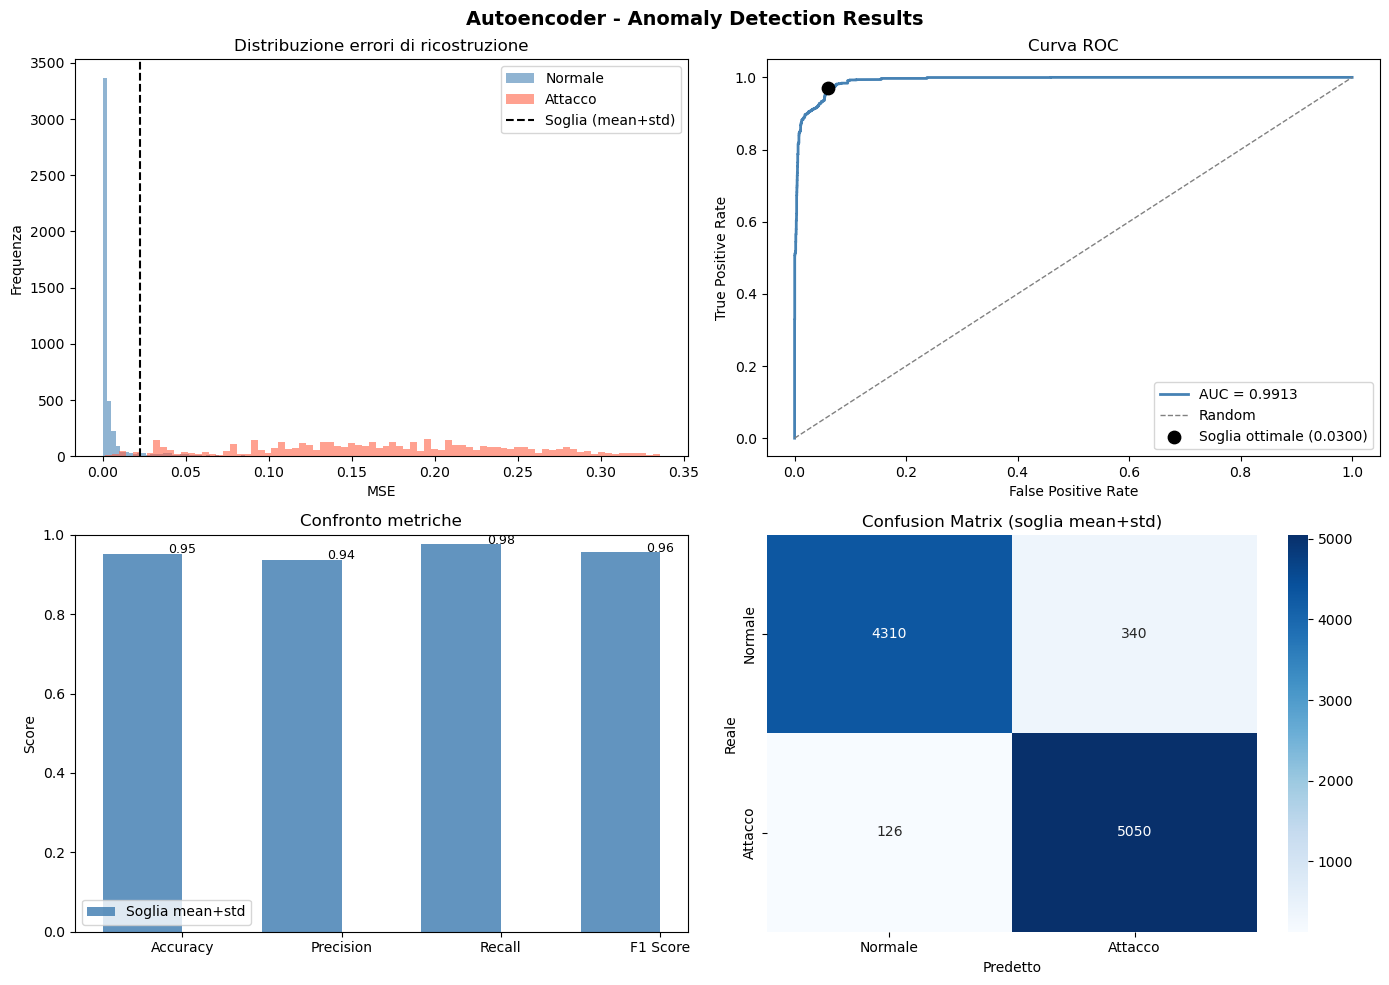

In [110]:
# GRAFICO

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, confusion_matrix
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Autoencoder - Anomaly Detection Results', fontsize=14, fontweight='bold')

# ── 1. Distribuzione MSE ──────────────────────────────────────────
ax1 = axes[0, 0]
ax1.hist(test_mse[Y_test == 0], bins=80, alpha=0.6, color='steelblue', label='Normale')
ax1.hist(test_mse[Y_test == 1], bins=80, alpha=0.6, color='tomato',    label='Attacco')
ax1.axvline(threshold, color='black', linestyle='--', linewidth=1.5, label='Soglia (mean+std)')
#ax1.axvline(np.mean(val_mse), color='gray',  linestyle=':',  linewidth=1.5, label='Soglia (mean)')
ax1.set_xlabel('MSE')
ax1.set_ylabel('Frequenza')
ax1.set_title('Distribuzione errori di ricostruzione')
ax1.legend()

# ── 2. Curva ROC ──────────────────────────────────────────────────
ax2 = axes[0, 1]
fpr, tpr, thresholds = roc_curve(Y_test, test_mse)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

ax2.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'AUC = 0.9913')
ax2.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Random')
ax2.scatter(fpr[optimal_idx], tpr[optimal_idx], color='black', zorder=5, s=80, label=f'Soglia ottimale ({optimal_threshold:.4f})')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('Curva ROC')
ax2.legend()

# ── 3. Confronto metriche tra le due soglie ───────────────────────
ax3 = axes[1, 0]
metrics_labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values_mse   = [0.9526, 0.9369, 0.9757, 0.9559]  # mean + std

x = np.arange(len(metrics_labels))
width = 0.5
ax3.bar(x - width/2, values_mse,  width, label='Soglia mean+std', color='steelblue', alpha=0.85)
ax3.set_xticks(x)
ax3.set_xticklabels(metrics_labels)
ax3.set_ylim(0, 1)
ax3.set_ylabel('Score')
ax3.set_title('Confronto metriche')
ax3.legend()
for i, v in enumerate(values_mse):
    ax3.text(i, v + 0.002, f'{v:.2f}', ha='center', fontsize=9)
    #ax3.text(i + width/2, v2 + 0.002, f'{v2:.2f}', ha='center', fontsize=9)

# ── 4. Confusion Matrix ───────────────────────────────────────────
ax4 = axes[1, 1]
cm = confusion_matrix(Y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax4,
            xticklabels=['Normale', 'Attacco'],
            yticklabels=['Normale', 'Attacco'])
ax4.set_xlabel('Predetto')
ax4.set_ylabel('Reale')
ax4.set_title('Confusion Matrix (soglia mean+std)')

plt.tight_layout()
plt.show()

In [75]:
# SALVATAGGIO

import joblib

autoencoder.save('autoencoder_model.keras')
joblib.dump(threshold, 'threshold.pkl')

['threshold.pkl']

# Acess-logs-3

IP malevoli: 151.59.134.10, 151.59.134.15, 151.59.128.186, 151.59.132.209

all bruteforce

## Preprocessing

In [88]:
import pandas as pd

df = pd.read_csv("datasets/access-logs-3.csv")
df.columns = [
    "timestamp",
    "Response",
    "IP",
    "IntervalDateTime",
    "Total",
    "Response_bytes",
    "Method",
    "host"
]
df.head()

,timestamp,Response,IP,IntervalDateTime,Total,Response_bytes,Method,host
0,1.775750e+09,20x,80.211.146.125,09/Apr/2026:15:47:05-09/Apr/2026:15:47:05,1,31,POST,www.sardegnasolidale.it
1,1.775750e+09,20x,198.244.242.27,09/Apr/2026:15:47:23-09/Apr/2026:15:47:23,1,589,GET,www.sardegnasolidale.it
2,1.775750e+09,20x,80.211.146.125,09/Apr/2026:15:49:08-09/Apr/2026:15:49:08,1,31,POST,www.sardegnasolidale.it
3,1.775750e+09,20x,216.75.132.174,09/Apr/2026:15:49:08-09/Apr/2026:15:49:08,1,497,GET,www.sardegnasolidale.it
4,1.775750e+09,20x,198.244.183.74,09/Apr/2026:15:49:22-09/Apr/2026:15:49:22,1,524,GET,www.sardegnasolidale.it


In [89]:
malicious_ips = [
    "151.59.134.10",
    "151.59.134.15",
    "151.59.128.186",
    "151.59.132.209"
]

df["label"] = df["IP"].isin(malicious_ips).astype(int)
print(df["label"].value_counts())
df.head()

label
0    32539
1    23941
Name: count, dtype: int64


,timestamp,Response,IP,IntervalDateTime,Total,Response_bytes,Method,host,label
0,1.775750e+09,20x,80.211.146.125,09/Apr/2026:15:47:05-09/Apr/2026:15:47:05,1,31,POST,www.sardegnasolidale.it,0
1,1.775750e+09,20x,198.244.242.27,09/Apr/2026:15:47:23-09/Apr/2026:15:47:23,1,589,GET,www.sardegnasolidale.it,0
2,1.775750e+09,20x,80.211.146.125,09/Apr/2026:15:49:08-09/Apr/2026:15:49:08,1,31,POST,www.sardegnasolidale.it,0
3,1.775750e+09,20x,216.75.132.174,09/Apr/2026:15:49:08-09/Apr/2026:15:49:08,1,497,GET,www.sardegnasolidale.it,0
4,1.775750e+09,20x,198.244.183.74,09/Apr/2026:15:49:22-09/Apr/2026:15:49:22,1,524,GET,www.sardegnasolidale.it,0


In [90]:
df[["start", "end"]] = (
    df["IntervalDateTime"]
    .astype(str)
    .str.replace('"', '', regex=False)
    .str.split("-", expand=True)
)

df["start"] = pd.to_datetime(df["start"], format="%d/%b/%Y:%H:%M:%S", errors="coerce")
df["end"]   = pd.to_datetime(df["end"],   format="%d/%b/%Y:%H:%M:%S", errors="coerce")

df["duration_sec"] = (df["end"] - df["start"]).dt.total_seconds()

df = df.reindex(columns=desired_order)

df.head()

,host,IP,IntervalDateTime,start,end,duration_sec,Total,Method,Response,Response_bytes,label
0,www.sardegnasolidale.it,80.211.146.125,09/Apr/2026:15:47:05-09/Apr/2026:15:47:05,2026-04-09 15:47:05,2026-04-09 15:47:05,0.0,1,POST,20x,31,0
1,www.sardegnasolidale.it,198.244.242.27,09/Apr/2026:15:47:23-09/Apr/2026:15:47:23,2026-04-09 15:47:23,2026-04-09 15:47:23,0.0,1,GET,20x,589,0
2,www.sardegnasolidale.it,80.211.146.125,09/Apr/2026:15:49:08-09/Apr/2026:15:49:08,2026-04-09 15:49:08,2026-04-09 15:49:08,0.0,1,POST,20x,31,0
3,www.sardegnasolidale.it,216.75.132.174,09/Apr/2026:15:49:08-09/Apr/2026:15:49:08,2026-04-09 15:49:08,2026-04-09 15:49:08,0.0,1,GET,20x,497,0
4,www.sardegnasolidale.it,198.244.183.74,09/Apr/2026:15:49:22-09/Apr/2026:15:49:22,2026-04-09 15:49:22,2026-04-09 15:49:22,0.0,1,GET,20x,524,0


In [91]:
# IP -> frequency encoding
df["IP_freq"] = df["IP"].map(df["IP"].value_counts())

# Method -> dummy encoding
df = pd.get_dummies(df, columns=["Method"], drop_first=False, dtype=int)

df.head()

,host,IP,IntervalDateTime,start,end,duration_sec,Total,Response,Response_bytes,label,IP_freq,Method_GET,Method_OTHER,Method_POST
0,www.sardegnasolidale.it,80.211.146.125,09/Apr/2026:15:47:05-09/Apr/2026:15:47:05,2026-04-09 15:47:05,2026-04-09 15:47:05,0.0,1,20x,31,0,5313,0,0,1
1,www.sardegnasolidale.it,198.244.242.27,09/Apr/2026:15:47:23-09/Apr/2026:15:47:23,2026-04-09 15:47:23,2026-04-09 15:47:23,0.0,1,20x,589,0,1,1,0,0
2,www.sardegnasolidale.it,80.211.146.125,09/Apr/2026:15:49:08-09/Apr/2026:15:49:08,2026-04-09 15:49:08,2026-04-09 15:49:08,0.0,1,20x,31,0,5313,0,0,1
3,www.sardegnasolidale.it,216.75.132.174,09/Apr/2026:15:49:08-09/Apr/2026:15:49:08,2026-04-09 15:49:08,2026-04-09 15:49:08,0.0,1,20x,497,0,1,1,0,0
4,www.sardegnasolidale.it,198.244.183.74,09/Apr/2026:15:49:22-09/Apr/2026:15:49:22,2026-04-09 15:49:22,2026-04-09 15:49:22,0.0,1,20x,524,0,2,1,0,0


In [92]:
df = df.drop(["IntervalDateTime", "host", "start", "end", "IP", "Response"], axis=1)

In [93]:
# Check negative values (to avoid making NA in log trasnform)
(df.select_dtypes(include="number") <= -1).sum()

# Drop negative values (before log transform)
df = df[(df > -1).all(axis=1)]

In [94]:
# Normalize values (min max scaler)
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Log-transform skewed features
df["duration_sec"] = np.log1p(df["duration_sec"])
df["Response_bytes"] = np.log1p(df["Response_bytes"])
df["IP_freq"] = np.log1p(df["IP_freq"])
df["Total"] = np.log1p(df["Total"])

# Scale selected features
features_to_scale = ["duration_sec", "Response_bytes", "IP_freq", "Total"]

scaler = MinMaxScaler()
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])
df = df.reindex(columns=["duration_sec", "Total", "Response_bytes", "IP_freq", "Method_GET", "Method_OTHER", "Method_POST", "label"])
df.head()

,duration_sec,Total,Response_bytes,IP_freq,Method_GET,Method_OTHER,Method_POST,label
0,0.0,0.0,0.197165,0.942223,0,0,1,0
1,0.0,0.0,0.362963,0.000000,1,0,0,0
2,0.0,0.0,0.197165,0.942223,0,0,1,0
3,0.0,0.0,0.353319,0.000000,1,0,0,0
4,0.0,0.0,0.356323,0.048452,1,0,0,0


In [95]:
important_feat

['IP_freq', 'Total', 'duration_sec', 'Response_bytes']

## Auto Encoder

In [96]:
# RISULTATI DELLE METRICHE UTILIZZANDO IL MODELLO PRECEDENTEMENTE ADDESTRATO CON ACCESS-LOGS2

from tensorflow import keras
import joblib
from sklearn.metrics import roc_auc_score
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    precision_score,
    recall_score
)

X_test = df[important_feat].values
Y_test = df["label"].values

autoencoder = keras.models.load_model('autoencoder_model.keras')
threshold   = joblib.load('threshold.pkl')

reconstructed = autoencoder.predict(X_test)
mse = np.mean(np.power(X_test - reconstructed, 2), axis=1)
y_pred = (mse > threshold).astype(int)

# Metrics
accuracy = accuracy_score(Y_test, y_pred)
precision = precision_score(Y_test, y_pred, zero_division=0)
recall = recall_score(Y_test, y_pred, zero_division=0)
f1 = f1_score(Y_test, y_pred, zero_division=0)

print("Metrics:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print(f"AUC-ROC: {roc_auc_score(Y_test, mse):.4f}")

1765/1765 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Metrics:
Accuracy : 0.9281
Precision: 0.8764
Recall   : 0.9667
F1 Score : 0.9193
AUC-ROC: 0.9627


# Access-log-4

IP malevolo: 77.89.34.239

## Preprocessing

In [98]:
import pandas as pd

df = pd.read_csv("datasets/access-logs-4.csv")
df.columns = [
    "timestamp",
    "Response_bytes",
    "Response",
    "Method",
    "host",
    "IP",
    "IntervalDateTime",
    "Total"
]
df.head()

,timestamp,Response_bytes,Response,Method,host,IP,IntervalDateTime,Total
0,1.776094e+09,2797564,20x,GET,www.sardegnasolidale.it,78.212.92.116,13/Apr/2026:15:32:01-13/Apr/2026:15:32:03,75
1,1.776094e+09,29929,20x,GET,www.sardegnasolidale.it,14.244.118.57,13/Apr/2026:15:31:56-13/Apr/2026:15:31:56,1
2,1.776094e+09,557,20x,GET,www.sardegnasolidale.it,165.16.183.78,13/Apr/2026:15:32:00-13/Apr/2026:15:32:00,1
3,1.776094e+09,664,20x,GET,www.sardegnasolidale.it,51.75.236.137,13/Apr/2026:15:32:02-13/Apr/2026:15:32:02,1
4,1.776094e+09,13595,20x,POST,www.sardegnasolidale.it,77.89.34.239,13/Apr/2026:15:32:36-13/Apr/2026:15:32:40,5


In [99]:
# labeling the attack ips
malicious_ips = [
"77.89.34.239",
]

df["label"] = df["IP"].isin(malicious_ips).astype(int)
print(df["label"].value_counts())
df.head()

label
1    86513
0    82791
Name: count, dtype: int64


,timestamp,Response_bytes,Response,Method,host,IP,IntervalDateTime,Total,label
0,1.776094e+09,2797564,20x,GET,www.sardegnasolidale.it,78.212.92.116,13/Apr/2026:15:32:01-13/Apr/2026:15:32:03,75,0
1,1.776094e+09,29929,20x,GET,www.sardegnasolidale.it,14.244.118.57,13/Apr/2026:15:31:56-13/Apr/2026:15:31:56,1,0
2,1.776094e+09,557,20x,GET,www.sardegnasolidale.it,165.16.183.78,13/Apr/2026:15:32:00-13/Apr/2026:15:32:00,1,0
3,1.776094e+09,664,20x,GET,www.sardegnasolidale.it,51.75.236.137,13/Apr/2026:15:32:02-13/Apr/2026:15:32:02,1,0
4,1.776094e+09,13595,20x,POST,www.sardegnasolidale.it,77.89.34.239,13/Apr/2026:15:32:36-13/Apr/2026:15:32:40,5,1


In [100]:
desired_order = [
    "host",
    "IP",
    "IntervalDateTime",
    "start",
    "end",
    "duration_sec",
    "Total",
    "Method",
    "Response",
    "Response_bytes",
    "label"
]

df[["start", "end"]] = (
    df["IntervalDateTime"]
    .astype(str)
    .str.replace('"', '', regex=False)
    .str.split("-", expand=True)
)

df["start"] = pd.to_datetime(df["start"], format="%d/%b/%Y:%H:%M:%S", errors="coerce")
df["end"]   = pd.to_datetime(df["end"],   format="%d/%b/%Y:%H:%M:%S", errors="coerce")

df["duration_sec"] = (df["end"] - df["start"]).dt.total_seconds()

df = df.reindex(columns=desired_order)

df.head()

,host,IP,IntervalDateTime,start,end,duration_sec,Total,Method,Response,Response_bytes,label
0,www.sardegnasolidale.it,78.212.92.116,13/Apr/2026:15:32:01-13/Apr/2026:15:32:03,2026-04-13 15:32:01,2026-04-13 15:32:03,2.0,75,GET,20x,2797564,0
1,www.sardegnasolidale.it,14.244.118.57,13/Apr/2026:15:31:56-13/Apr/2026:15:31:56,2026-04-13 15:31:56,2026-04-13 15:31:56,0.0,1,GET,20x,29929,0
2,www.sardegnasolidale.it,165.16.183.78,13/Apr/2026:15:32:00-13/Apr/2026:15:32:00,2026-04-13 15:32:00,2026-04-13 15:32:00,0.0,1,GET,20x,557,0
3,www.sardegnasolidale.it,51.75.236.137,13/Apr/2026:15:32:02-13/Apr/2026:15:32:02,2026-04-13 15:32:02,2026-04-13 15:32:02,0.0,1,GET,20x,664,0
4,www.sardegnasolidale.it,77.89.34.239,13/Apr/2026:15:32:36-13/Apr/2026:15:32:40,2026-04-13 15:32:36,2026-04-13 15:32:40,4.0,5,POST,20x,13595,1


In [101]:
# Encode categorical features
# # Response -> ordinal
# response_map = {
#     "20x": 0, # normal
#     "30x": 1, # transitional
#     "40x": 2, # problematic
#     "49x": 3  # suspicious
# }
# df["Response"] = df["Response"].map(response_map)

# IP -> frequency encoding
df["IP_freq"] = df["IP"].map(df["IP"].value_counts())

# Method -> dummy encoding
df = pd.get_dummies(df, columns=["Method"], drop_first=False, dtype=int)

df.head()

,host,IP,IntervalDateTime,start,end,duration_sec,Total,Response,Response_bytes,label,IP_freq,Method_GET,Method_OTHER,Method_POST
0,www.sardegnasolidale.it,78.212.92.116,13/Apr/2026:15:32:01-13/Apr/2026:15:32:03,2026-04-13 15:32:01,2026-04-13 15:32:03,2.0,75,20x,2797564,0,2,1,0,0
1,www.sardegnasolidale.it,14.244.118.57,13/Apr/2026:15:31:56-13/Apr/2026:15:31:56,2026-04-13 15:31:56,2026-04-13 15:31:56,0.0,1,20x,29929,0,1,1,0,0
2,www.sardegnasolidale.it,165.16.183.78,13/Apr/2026:15:32:00-13/Apr/2026:15:32:00,2026-04-13 15:32:00,2026-04-13 15:32:00,0.0,1,20x,557,0,1,1,0,0
3,www.sardegnasolidale.it,51.75.236.137,13/Apr/2026:15:32:02-13/Apr/2026:15:32:02,2026-04-13 15:32:02,2026-04-13 15:32:02,0.0,1,20x,664,0,3,1,0,0
4,www.sardegnasolidale.it,77.89.34.239,13/Apr/2026:15:32:36-13/Apr/2026:15:32:40,2026-04-13 15:32:36,2026-04-13 15:32:40,4.0,5,20x,13595,1,86513,0,0,1


In [102]:
# Drop unnecessary columns
df = df.drop(["IntervalDateTime", "host", "start", "end", "IP", "Response"], axis=1)

df.head()

,duration_sec,Total,Response_bytes,label,IP_freq,Method_GET,Method_OTHER,Method_POST
0,2.0,75,2797564,0,2,1,0,0
1,0.0,1,29929,0,1,1,0,0
2,0.0,1,557,0,1,1,0,0
3,0.0,1,664,0,3,1,0,0
4,4.0,5,13595,1,86513,0,0,1


In [103]:
# Check NA values
df.isna().sum()

duration_sec      0
Total             0
Response_bytes    0
label             0
IP_freq           0
Method_GET        0
Method_OTHER      0
Method_POST       0
dtype: int64

In [104]:
# Check negative values (to avoid making NA in log trasnform)
(df.select_dtypes(include="number") <= -1).sum()

# Drop negative values (before log transform)
df = df[(df > -1).all(axis=1)]

In [105]:
# Normalize values (min max scaler)
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Log-transform skewed features
df["duration_sec"] = np.log1p(df["duration_sec"])
df["Response_bytes"] = np.log1p(df["Response_bytes"])
df["IP_freq"] = np.log1p(df["IP_freq"])
df["Total"] = np.log1p(df["Total"])

# Scale selected features
features_to_scale = ["duration_sec", "Response_bytes", "IP_freq", "Total"]

scaler = MinMaxScaler()
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])
df = df.reindex(columns=["duration_sec", "Total", "Response_bytes", "IP_freq", "Method_GET", "Method_OTHER", "Method_POST", "label"])
df.head()

,duration_sec,Total,Response_bytes,IP_freq,Method_GET,Method_OTHER,Method_POST,label
0,0.250000,0.746727,0.862626,0.037983,1,0,0,0
1,0.000000,0.000000,0.598935,0.000000,1,0,0,0
2,0.000000,0.000000,0.367519,0.000000,1,0,0,0
3,0.000000,0.000000,0.377714,0.064932,1,0,0,0
4,0.366243,0.225524,0.553080,1.000000,0,0,1,1


In [106]:
important_feat

['IP_freq', 'Total', 'duration_sec', 'Response_bytes']

## Auto Encoder

In [107]:
# RISULTATI DELLE METRICHE UTILIZZANDO IL MODELLO PRECEDENTEMENTE ADDESTRATO CON ACCESS-LOGS2

from tensorflow import keras
import joblib
from sklearn.metrics import roc_auc_score
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    precision_score,
    recall_score
)

X_test = df[important_feat].values
Y_test = df["label"].values

autoencoder = keras.models.load_model('autoencoder_model.keras')
threshold   = joblib.load('threshold.pkl')

reconstructed = autoencoder.predict(X_test)
mse = np.mean(np.power(X_test - reconstructed, 2), axis=1)
y_pred = (mse > threshold).astype(int)

# Metrics
accuracy = accuracy_score(Y_test, y_pred)
precision = precision_score(Y_test, y_pred, zero_division=0)
recall = recall_score(Y_test, y_pred, zero_division=0)
f1 = f1_score(Y_test, y_pred, zero_division=0)

print("Metrics:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print(f"AUC-ROC: {roc_auc_score(Y_test, mse):.4f}")

5291/5291 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step
Metrics:
Accuracy : 0.9314
Precision: 0.8920
Recall   : 0.9851
F1 Score : 0.9362
AUC-ROC: 0.9832
